<a href="https://colab.research.google.com/github/dookda/cmu_py499/blob/main/proj_jan/get_azimuth_for_gsv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
from google.colab import drive
drive.mount('/content/drive/')

road = "/content/drive/MyDrive/_DATASET/cm_uban_road_split_4326.geojson"

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
# install python package
!pip install geopandas shapely pyproj

In [48]:
import geopandas as gpd
import numpy as np
from shapely.geometry import LineString, MultiLineString

# Function to calculate azimuth between two points (lon1, lat1) and (lon2, lat2)
def calculate_azimuth(start_point, end_point):
    lon1, lat1 = start_point
    lon2, lat2 = end_point

    # Check for identical points (degenerate case)
    if (lon1 == lon2) and (lat1 == lat2):
        return np.nan  # Undefined azimuth for identical points

    # Convert latitude and longitude to radians
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    # Calculate differences
    dlon = lon2 - lon1

    # Calculate azimuth using the haversine formula for bearing
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    azimuth = np.arctan2(x, y)

    # Convert azimuth from radians to degrees and normalize to 0-360
    azimuth = np.degrees(azimuth)
    azimuth = (azimuth + 360) % 360

    return azimuth

# Load the GeoJSON file
try:
    gdf = gpd.read_file(road)
except Exception as e:
    print(f"Error loading GeoJSON file: {e}")
    exit()

# Ensure the CRS is EPSG:4326
if gdf.crs is None or gdf.crs != 'EPSG:4326':
    print("Setting CRS to EPSG:4326")
    gdf = gdf.set_crs('EPSG:4326')

# Initialize lists to store azimuth values and error messages
azimuths = []
error_log = []

# Iterate over each geometry in the GeoDataFrame
for idx, geom in enumerate(gdf.geometry):
    try:
        if geom is None:
            azimuths.append(np.nan)
            error_log.append((idx, "Geometry is None"))
            continue

        if isinstance(geom, LineString) and len(geom.coords) >= 2:
            coords = list(geom.coords)
            start_point = coords[0]  # (lon1, lat1)
            end_point = coords[-1]   # (lon2, lat2)
            # Validate coordinates
            if any(not (-180 <= lon <= 180 and -90 <= lat <= 90) for lon, lat in [start_point, end_point]):
                azimuths.append(np.nan)
                error_log.append((idx, f"Invalid coordinates: {start_point}, {end_point}"))
                continue
            azimuth = calculate_azimuth(start_point, end_point)
            azimuths.append(azimuth)
        elif isinstance(geom, MultiLineString) and len(geom.geoms) > 0:
            # Handle MultiLineString by taking the first LineString
            first_line = geom.geoms[0]
            if len(first_line.coords) >= 2:
                coords = list(first_line.coords)
                start_point = coords[0]
                end_point = coords[-1]
                if any(not (-180 <= lon <= 180 and -90 <= lat <= 90) for lon, lat in [start_point, end_point]):
                    azimuths.append(np.nan)
                    error_log.append((idx, f"Invalid coordinates in MultiLineString: {start_point}, {end_point}"))
                    continue
                azimuth = calculate_azimuth(start_point, end_point)
                azimuths.append(azimuth)
            else:
                azimuths.append(np.nan)
                error_log.append((idx, "MultiLineString has LineString with < 2 points"))
        else:
            azimuths.append(np.nan)
            error_log.append((idx, f"Invalid geometry type or insufficient points: {type(geom).__name__}, {len(geom.coords) if hasattr(geom, 'coords') else 'N/A'}"))

    except Exception as e:
        azimuths.append(np.nan)
        error_log.append((idx, f"Error processing geometry: {str(e)}"))

# Add azimuth column to the GeoDataFrame
gdf['azimuth'] = azimuths

# Save the updated GeoDataFrame to a new GeoJSON file (optional)
try:
    gdf.to_file('road_with_azimuth.geojson', driver='GeoJSON')
except Exception as e:
    print(f"Error saving GeoJSON file: {e}")

# Print the GeoDataFrame to inspect results
print(gdf[['geometry', 'azimuth']])

# Print error log for rows with NaN azimuths
if error_log:
    print("\nRows with NaN azimuths and reasons:")
    for idx, reason in error_log:
        print(f"Row {idx}: {reason}")

# Optional: Filter and print rows with valid azimuths
valid_gdf = gdf[gdf['azimuth'].notna()]
print("\nRows with valid azimuths:")
print(valid_gdf[['geometry', 'azimuth']])

                                              geometry     azimuth
0    MULTILINESTRING ((99.02504 18.74913, 99.02492 ...  347.698574
1    MULTILINESTRING ((98.98713 18.84535, 98.98717 ...  161.098691
2    MULTILINESTRING ((98.97386 18.83974, 98.9746 1...   76.772666
3    MULTILINESTRING ((98.97776 18.84061, 98.97781 ...  173.776566
4    MULTILINESTRING ((98.97796 18.83889, 98.97792 ...  249.690735
..                                                 ...         ...
651  MULTILINESTRING ((98.914 18.76026, 98.91381 18...  243.831484
652  MULTILINESTRING ((98.90241 18.80297, 98.90381 ...   94.409368
653  MULTILINESTRING ((98.92091 18.80162, 98.92096 ...  119.521507
654  MULTILINESTRING ((98.93328 18.79499, 98.93326 ...   41.040119
655  MULTILINESTRING ((99.02335 18.80749, 99.02191 ...  233.068879

[656 rows x 2 columns]

Rows with valid azimuths:
                                              geometry     azimuth
0    MULTILINESTRING ((99.02504 18.74913, 99.02492 ...  347.698574
1    MULTIL

In [49]:
import geopandas as gpd
from shapely.geometry import Point
import shapely
import math

# === 1. โหลดเส้นถนน ===
gdf = gpd.read_file("/content/road_with_azimuth.geojson")  # ← เปลี่ยนตามไฟล์คุณ

# === 2. แปลง CRS เป็นแบบ UTM (หน่วยเป็นเมตร) ===
if gdf.crs.is_geographic:
    gdf = gdf.to_crs(gdf.estimate_utm_crs())

# === 3. สร้างจุดทุก 200 เมตรจากแต่ละเส้น ===
point_list = []

for idx, row in gdf.iterrows():
    line = row.geometry
    if line is None or not line.length > 0:
        continue

    distance = 0
    while distance < line.length:
        point = line.interpolate(distance)
        properties = row.drop("geometry").to_dict()
        point_list.append({**properties, "geometry": point})
        distance += 200  # ทุก 200 เมตร

# === 4. สร้าง GeoDataFrame ของจุด ===
points_gdf = gpd.GeoDataFrame(point_list, crs=gdf.crs)

# === 5. (เลือก) แปลงกลับเป็น EPSG:4326 (Lat/Lon) สำหรับ Web Mapping หรือ GeoJSON
points_gdf = points_gdf.to_crs(epsg=4326)

# === 6. บันทึกเป็น GeoJSON ===
points_gdf.to_file("road_points_200m.geojson", driver="GeoJSON")

print(f"✅ Generated {len(points_gdf)} points and saved as road_points_200m.geojson")


✅ Generated 1655 points and saved as road_points_200m.geojson


In [60]:
# read "road_points_200m.geojson" and print
import geopandas as gpd
gdf = gpd.read_file("road_points_200m.geojson")
gdf.head()

,LENGTH,TRANS_TYP,TYP_T,TRANS_NO,NAME_T,NAME_E,TranNo,TranTyp_n,azimuth,geometry
0,23119.874,8,ทางรถไฟ,None,ทางรถไฟสายเหนือ,NORTHERN RAILWAY,0,8,347.698574,POINT (99.02504 18.74913)
1,23119.874,8,ทางรถไฟ,None,ทางรถไฟสายเหนือ,NORTHERN RAILWAY,0,8,347.698574,POINT (99.02432 18.7508)
2,23119.874,8,ทางรถไฟ,None,ทางรถไฟสายเหนือ,NORTHERN RAILWAY,0,8,347.698574,POINT (99.0236 18.75247)
3,23119.874,8,ทางรถไฟ,None,ทางรถไฟสายเหนือ,NORTHERN RAILWAY,0,8,347.698574,POINT (99.02288 18.75414)
4,23119.874,8,ทางรถไฟ,None,ทางรถไฟสายเหนือ,NORTHERN RAILWAY,0,8,347.698574,POINT (99.02216 18.75581)


347.69857385023414


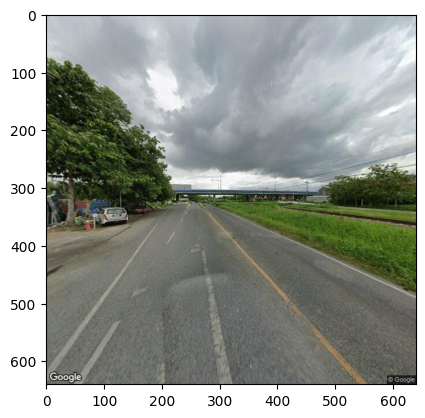

347.69857385023414


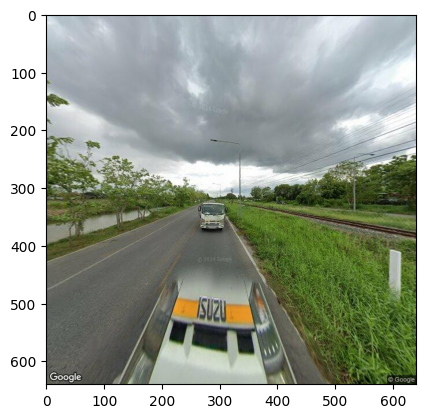

347.69857385023414


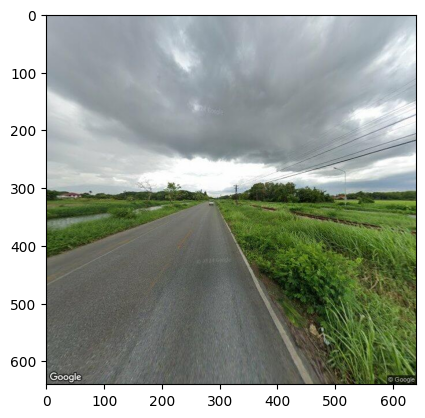

347.69857385023414


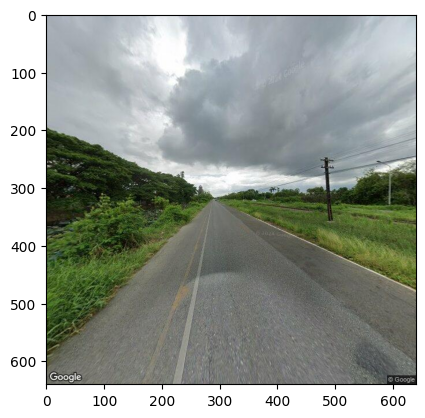

347.69857385023414


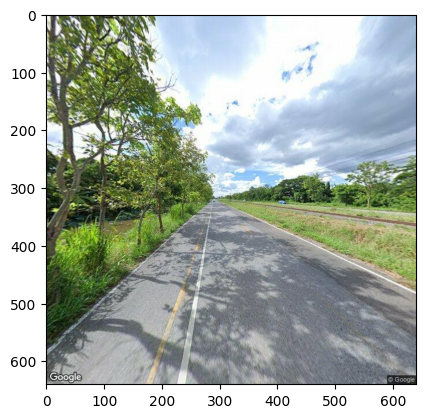

347.69857385023414


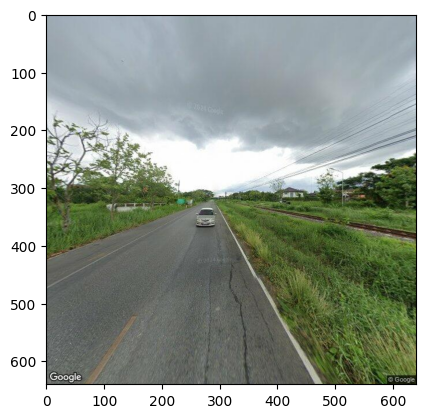

347.69857385023414


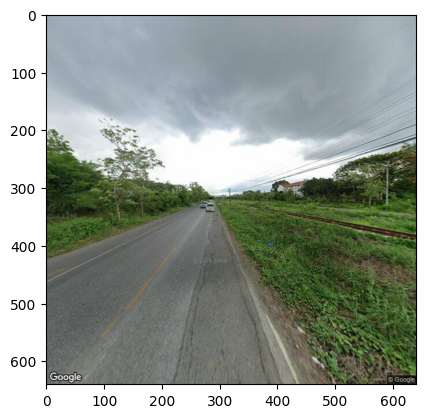

347.69857385023414


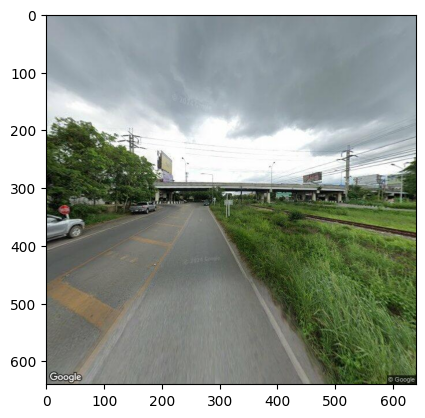

347.69857385023414


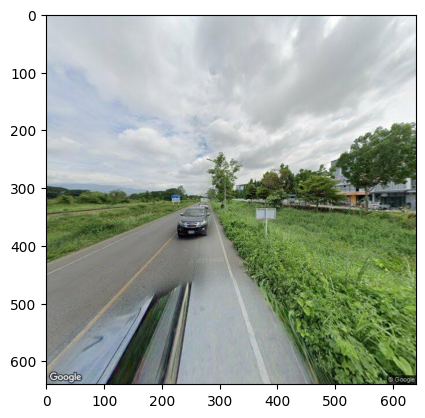

347.69857385023414


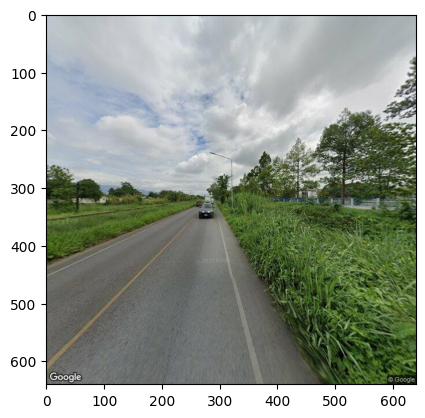

In [79]:
# read "road_points_200m.geojson" and print
import geopandas as gpd
gdf = gpd.read_file("road_points_200m.geojson")
# gdf.head()


# Your Google API key
API_KEY = "AIzxxxxxxxxxxxxxxxxxxxxxxxxxx"

for i in range(10):
  # print(gdf.geometry[i].x, gdf.geometry[i].y)
  lat, lon, azimuth = gdf.geometry[i].y, gdf.geometry[i].x, gdf['azimuth'].iloc[i]

  print(azimuth)

  # Step 1: Get metadata to find heading (pano_yaw_deg)
  meta_url = (
      f"https://maps.googleapis.com/maps/api/streetview/metadata"
      f"?location={lat},{lon}&key={API_KEY}"
  )
  meta_response = requests.get(meta_url).json()

  # print(meta_response)

  if meta_response['status'] == 'OK':
      pano_id = meta_response.get('pano_id')
      heading = int(azimuth)

      # Step 2: Get street view image facing forward
      image_url = (
        f"https://maps.googleapis.com/maps/api/streetview"
        f"?size=640x640"
        f"&location={lat},{lon}"
        f"&heading={heading}"
        f"&pitch=0"
        f"&fov=180"
        f"&key={API_KEY}"
      )

      # Save image
      img_name = "streetview_" + str(pano_id) + ".jpg"
      image_data = requests.get(image_url).content
      with open(img_name, "wb") as f:
          f.write(image_data)

      # show as picture as matplotlib
      import matplotlib.pyplot as plt
      from PIL import Image
      import numpy as np
      image = Image.open(img_name)
      plt.imshow(image)
      plt.show()
  else:
      print("Street View not available for this location")

# for i in range(len(gdf)):
#   print(gdf.geometry[i])